# Notebook 03 — The competition

Time to compete. Every team plays the **same game**:

- everyone starts from the **same** `N_INITIAL` measured antibodies,
- each round your wet lab tests exactly `BATCH_SIZE` new antibodies,
- you have `N_ROUNDS` rounds, and
- your goal is to **maximize hypervolume as fast as possible**.

The score is **AUC-HV** — the area under your hypervolume-vs-round curve, so
growing the front *early* matters, not just at the end. Ties break on final HV,
then number of non-dominated antibodies found, then diversity.

The **only** thing you change is your `TEAM_STRATEGY`: the batch plan you play
each round. Everything else is locked.

## Locked setup (read-only)

These are fixed for every team — don't change them. We load the pool, the oracle
(noisy measurements only — `allow_true=False`), and the shared initial design.

In [1]:
import matplotlib.pyplot as plt
import torch

from mobo_lab import competition, config, data, metrics, plotting, seed
from mobo_lab.oracle import AntibodyOracle
from mobo_lab.pool import VHSequencePool

seed.set_all_seeds(config.SEED)

pool = VHSequencePool.from_files()
oracle = AntibodyOracle.from_files(allow_true=False)
initial_ids = data.load_initial_ids()

print("LOCKED competition settings")
print(f"  BATCH_SIZE = {config.BATCH_SIZE}  (antibodies per round)")
print(f"  N_ROUNDS   = {config.N_ROUNDS}    (rounds)")
print(f"  N_INITIAL  = {config.N_INITIAL}   (shared starting antibodies)")
print(f"  budget     = {config.TOTAL_NEW_EVALUATIONS} new evaluations total")
print(f"  pool size  = {len(pool)} candidate sequences")
print(f"  REF_POINT  = {config.REF_POINT}")

LOCKED competition settings
  BATCH_SIZE = 4  (antibodies per round)
  N_ROUNDS   = 6    (rounds)
  N_INITIAL  = 12   (shared starting antibodies)
  budget     = 24 new evaluations total
  pool size  = 2048 candidate sequences
  REF_POINT  = [-0.05, -0.05]


## ✏️ Your team's strategy (the only cell you edit)

`TEAM_STRATEGY` is a list of **one batch plan per round** (so its length must be
`N_ROUNDS`). Each plan's slots must add up to `BATCH_SIZE`. The cards you can play:
`nehvi`, `parego`, `scalarized_0.8_0.2`, `scalarized_0.2_0.8`, `scalarized_0.5_0.5`,
`random`, `uncertainty`.

Optionally switch the projection used for the continuous fallback with
`PROJECTION_METHOD` (`"nearest"` or `"diverse_nearest"`).

In [2]:
TEAM_NAME = "Team Example"

TEAM_STRATEGY = [
    {"nehvi": 4},
    {"nehvi": 3, "random": 1},
    {"parego": 4},
    {"nehvi": 2, "scalarized_0.5_0.5": 2},
    {"nehvi": 4},
    {"nehvi": 4},
]

PROJECTION_METHOD = "nearest"

# Check each plan before spending compute (friendly error if a round is malformed).
assert len(TEAM_STRATEGY) == config.N_ROUNDS, "TEAM_STRATEGY must have one plan per round"
from mobo_lab.strategies import validate_batch_plan

for round_plan in TEAM_STRATEGY:
    validate_batch_plan(round_plan)
print(f"{TEAM_NAME}: {len(TEAM_STRATEGY)} valid rounds, projection = {PROJECTION_METHOD}")

Team Example: 6 valid rounds, projection = nearest


## Run your campaign

`run_campaign` plays your plan round by round — fit the model, propose a batch,
measure it, update — and records the hypervolume after each round. It enforces the
rules for you: fixed batch size, no duplicates, never re-measure an antibody.

In [3]:
history = competition.run_campaign(
    TEAM_STRATEGY, TEAM_NAME, projection_method=PROJECTION_METHOD
)
competition.save_run_outputs(history)

print(f"AUC-HV   : {history['auc_hv']:.4f}   <- the score")
print(f"final HV : {history['final_hv']:.4f}")
print(f"non-dominated antibodies found: {history['n_nondominated_selected']}")
print("HV by round:", [round(h, 4) for h in history["hv_history"]])

AUC-HV   : 0.8602   <- the score
final HV : 1.0371
non-dominated antibodies found: 7
HV by round: [0.4209, 0.6573, 0.833, 0.9316, 0.9879, 1.0227, 1.0371]


## Your results

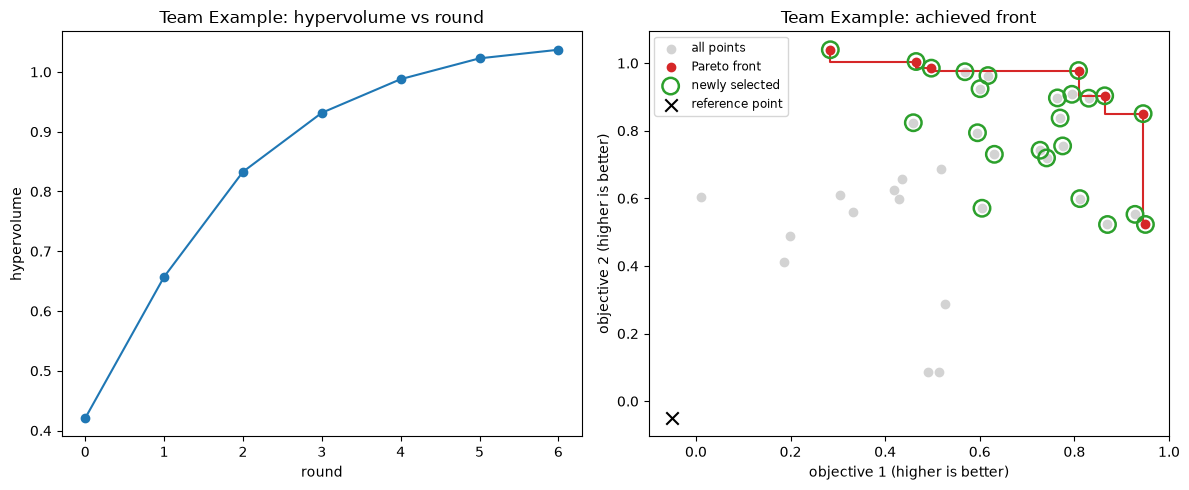

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plotting.plot_hv_curve(history["hv_history"], title=f"{TEAM_NAME}: hypervolume vs round", ax=axes[0])

final_Y = torch.tensor(history["final_Y"], dtype=torch.double)
selected = torch.zeros(final_Y.shape[0], dtype=torch.bool)
selected[history["n_initial"]:] = True
plotting.plot_pareto_front(
    final_Y, selected_mask=selected, ref_point=config.REF_POINT,
    title=f"{TEAM_NAME}: achieved front", ax=axes[1],
)
fig.tight_layout();

## Leaderboard

Once teams have saved their runs into `outputs/`, this ranks everyone by AUC-HV.
(Re-running your notebook overwrites your own entry — latest run wins.)

In [5]:
leaderboard = competition.update_leaderboard()
leaderboard

,team_name,auc_hv,final_hv,n_nondominated_selected,embedding_diversity
rank,,,,,
1,Team Example,0.860247,1.037111,7,0.517865


---
# Instructor section — the true Pareto front reveal

> Run by the instructor after the competition. It reconstructs the oracle with
> `allow_true=True` to expose the **hidden** objective landscape and overlay every
> team's achievement, turning the leaderboard into a scientific discussion.

true Pareto front: 7 points
wrote: /home/ji-won-park/stage/multi-objective-reasoning-lab/outputs/final_true_pareto_overlay.png


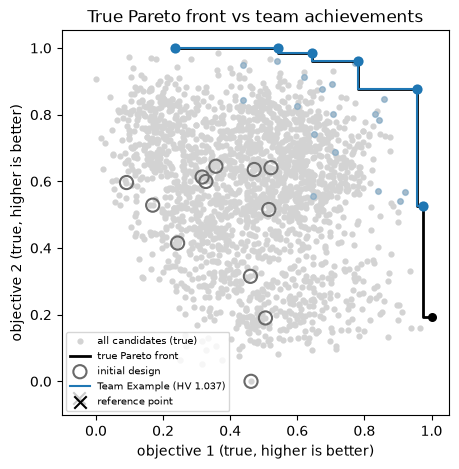

In [6]:
reveal_oracle = AntibodyOracle.from_files(allow_true=True)
true_front = metrics.compute_true_pareto_front(reveal_oracle.true_objectives)
print(f"true Pareto front: {true_front.shape[0]} points")

overlay_path = competition.build_final_debrief_report(
    config.OUTPUTS_DIR, reveal_oracle, initial_ids, config.REF_POINT
)
print("wrote:", overlay_path)

plotting.plot_true_front_with_team_overlays(
    reveal_oracle.true_objectives,
    initial_ids,
    competition.load_team_runs(),
    config.REF_POINT,
);

## Debrief prompts

With the true landscape visible, discuss:

1. **Which regions of the true front did teams find, and which did they miss?**
2. Where did a **fixed scalarization** over-focus — a corner exploited early but a
   chunk of the front left uncovered?
3. Where did **NEHVI / ParEGO** pay off, and where did spending a slot on
   **random / uncertainty** exploration uncover an otherwise-missed region?
4. Did `diverse_nearest` projection change which trade-offs a team reached?
5. Look at the AUC-HV vs final-HV ordering: did any team win the *race* (early HV)
   but not the *finish* (final HV), or vice versa? What does that say about their
   plan-per-round choices?